In [13]:
import kagglehub
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Supresión de warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Configuración de visualización del DataFrame
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuración de gráficos
sns.set_theme(style='whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

In [2]:

# ── Configuración ──────────────────────────────────────────
DATA_PATH = r"data/raw/inglaterra_argentina_wc_26_raw.csv"  
SEPARATOR = ','               
ENCODING  = "utf-8"             
# ───────────────────────────────────────────────────────────

df_raw = pd.read_csv(DATA_PATH, sep=SEPARATOR, encoding=ENCODING, header=1) # header=1 asigna a la fila 2 como header 
print(f"✅ Dataset cargado — Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")


✅ Dataset cargado — Filas: 32 | Columnas: 22


# LIMPIEZA

In [4]:
# ─── Primeras y últimas filas ──────────────────────────────────────────────
print('\n--- Primeras 5 filas ---')
display(df_raw.head())

print('\n--- Últimas 5 filas ---')
display(df_raw.tail())

# ─── Dimensiones ───────────────────────────────────────────────────────────
print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')

# ─── Tipos de datos ────────────────────────────────────────────────────────
print('\n--- Info general ---')
df_raw.info()

# ─── Valores nulos por columna ─────────────────────────────────────────────
print('\n--- Nulos por columna ---')
# Verificamos si hay algún nulo en toda la tabla
if df_raw.isnull().sum().sum() == 0:
    print('✅ Sin valores nulos')
else:
    # Sino mostramos tabla filtrada de nulos
    nulos = pd.DataFrame({
        'Nulos': df_raw.isnull().sum(),
        'Porcentaje': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
    })
    display(nulos[nulos['Nulos'] > 0])

# ─── Duplicados ────────────────────────────────────────────────────────────
print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')

# ─── Estadísticas descriptivas ─────────────────────────────────────────────
print('\n--- Estadísticas descriptivas ---')
display(df_raw.describe())


--- Primeras 5 filas ---


,Player,#,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon
0,Harry Kane,9,FW,32-352,90,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,NaN,NaN
1,Anthony Gordon,18,AM,25-141,71,1,0,0,0,1,1,0,0,1,1,0,2,0,0,0,NaN,NaN
2,Ezri Konsa,2,"DF,FW",28-265,19,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,NaN,NaN
3,Jude Bellingham,10,AM,23-016,90,0,0,0,0,0,0,0,0,3,4,0,0,1,1,0,NaN,NaN
4,Morgan Rogers,17,AM,23-354,90,0,1,0,0,1,0,0,0,2,1,1,4,0,0,0,NaN,NaN



--- Últimas 5 filas ---


,Player,#,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon
27,Nicolás Otamendi,19,DF,38-153,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
28,Cristian Romero,13,CB,28-079,90,0,0,0,0,0,0,1,0,2,1,0,0,3,2,0,NaN,NaN
29,Nahuel Molina,26,RB,28-100,71,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,NaN,NaN
30,Gonzalo Montiel,4,DF,29-195,19,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,NaN,NaN
31,Emiliano Martínez,23,GK,33-316,90,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,NaN,NaN


Filas: 32 | Columnas: 22

--- Info general ---
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  32 non-null     str    
 1   #       32 non-null     int64  
 2   Pos     32 non-null     str    
 3   Age     32 non-null     str    
 4   Min     32 non-null     int64  
 5   Gls     32 non-null     int64  
 6   Ast     32 non-null     int64  
 7   PK      32 non-null     int64  
 8   PKatt   32 non-null     int64  
 9   Sh      32 non-null     int64  
 10  SoT     32 non-null     int64  
 11  CrdY    32 non-null     int64  
 12  CrdR    32 non-null     int64  
 13  Fls     32 non-null     int64  
 14  Fld     32 non-null     int64  
 15  Off     32 non-null     int64  
 16  Crs     32 non-null     int64  
 17  TklW    32 non-null     int64  
 18  Int     32 non-null     int64  
 19  OG      32 non-null     int64  
 20  PKwon   0 non-null      float64
 21  PKcon

,Nulos,Porcentaje
PKwon,32,100.00
PKcon,32,100.00



Filas duplicadas: 0

--- Estadísticas descriptivas ---


,#,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,0.00,0.00
mean,12.59,61.88,0.09,0.09,0.00,0.00,0.62,0.22,0.12,0.00,0.81,0.81,0.12,1.06,0.56,0.47,0.00,NaN,NaN
std,7.89,34.44,0.30,0.39,0.00,0.00,1.01,0.42,0.34,0.00,1.20,1.09,0.34,1.76,0.98,0.67,0.00,NaN,NaN
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
25%,5.75,19.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
50%,10.50,80.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.50,0.00,0.00,0.00,NaN,NaN
75%,19.25,90.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,2.00,1.00,1.00,0.00,NaN,NaN
max,26.00,90.00,1.00,2.00,0.00,0.00,4.00,1.00,1.00,0.00,5.00,4.00,1.00,9.00,4.00,2.00,0.00,NaN,NaN


In [5]:
# ── Eliminar columna entera ────────────────────────────────────────────────
# Cuándo: más del 50% de nulos y la columna no aporta valor
df_raw = df_raw.drop(columns=['PKwon', 'PKcon'])        # ← reemplazar

In [6]:
# Opción A — quedarse solo con los años (más simple)
df_raw['Age'] = df_raw['Age'].str.split('-').str[0].astype(int)


In [7]:
# Ver si el índice tiene huecos
print(f'Índice antes del reset: {df_raw.index.tolist()[:10]}...')

# Resetear
df_raw = df_raw.reset_index(drop=True)

# Verificar
print(f'Índice después del reset: {df_raw.index.tolist()[:10]}...')
print(f'Filas finales: {df_raw.shape[0]}')

Índice antes del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Índice después del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Filas finales: 32


In [8]:
print('=' * 50)
print('REPORTE FINAL DE CALIDAD')
print('=' * 50)
print(f'Filas finales:      {df_raw.shape[0]}')
print(f'Columnas:           {df_raw.shape[1]}')
print(f'Duplicados:         {df_raw.duplicated().sum()}')
print(f'Nulos totales:      {df_raw.isnull().sum().sum()}')
print('=' * 50)

REPORTE FINAL DE CALIDAD
Filas finales:      32
Columnas:           20
Duplicados:         0
Nulos totales:      0


In [9]:
# Tipos de datos finales
print(df_raw.dtypes)

Player      str
#         int64
Pos         str
Age       int64
Min       int64
Gls       int64
Ast       int64
PK        int64
PKatt     int64
Sh        int64
SoT       int64
CrdY      int64
CrdR      int64
Fls       int64
Fld       int64
Off       int64
Crs       int64
TklW      int64
Int       int64
OG        int64
dtype: object


In [10]:
df_raw

,Player,#,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG
0,Harry Kane,9,FW,32,90,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0
1,Anthony Gordon,18,AM,25,71,1,0,0,0,1,1,0,0,1,1,0,2,0,0,0
2,Ezri Konsa,2,"DF,FW",28,19,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0
3,Jude Bellingham,10,AM,23,90,0,0,0,0,0,0,0,0,3,4,0,0,1,1,0
4,Morgan Rogers,17,AM,23,90,0,1,0,0,1,0,0,0,2,1,1,4,0,0,0
5,Elliot Anderson,8,DM,23,90,0,0,0,0,0,0,1,0,2,4,0,0,2,1,0
6,Declan Rice,4,DM,27,82,0,0,0,0,1,1,0,0,0,0,0,2,0,2,0
7,Nico O'Reilly,3,"DF,MF",21,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,Djed Spence,25,LB,25,89,0,0,0,0,0,0,0,0,0,1,0,1,4,2,0
9,Marcus Rashford,11,"FW,MF",28,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [11]:
# Renombrar a df_clean antes de exportar
df_clean = df_raw.copy()

# Exportar
nombre_salida = "data/clean/inglaterra_argentina_wc_26_clean.csv"    
df_clean.to_csv(nombre_salida, index=False, encoding='utf-8')
print(f'Dataset exportado: {nombre_salida}')
print(f'Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}')

Dataset exportado: data/clean/inglaterra_argentina_wc_26_clean.csv
Filas: 32 | Columnas: 20


# EDA

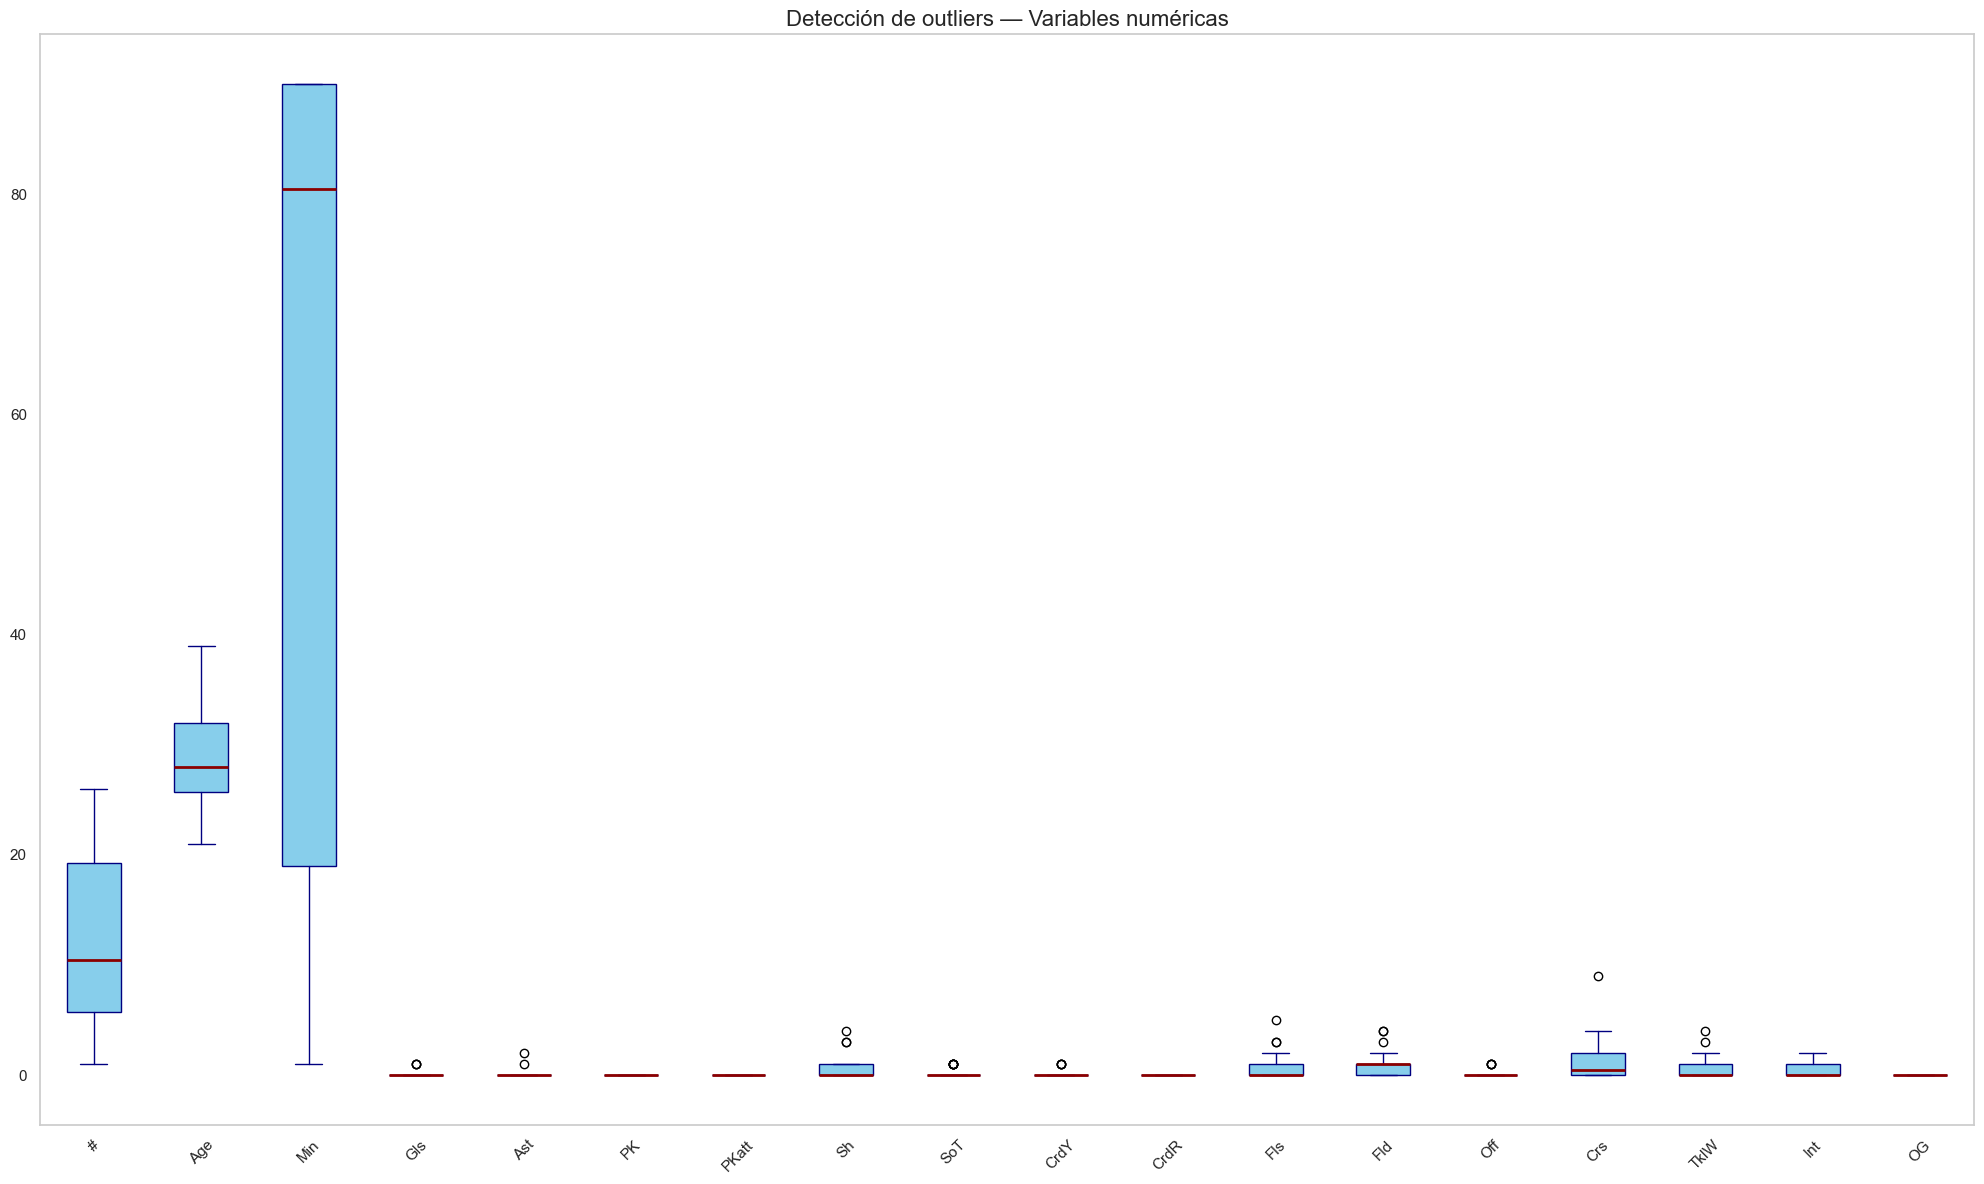

In [32]:
# Boxplot de todas las variables numéricas
plt.figure(figsize=(20, 12))
df_clean[columnas_numericas].boxplot(
    grid=False,                
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='navy'),   
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    medianprops=dict(color='darkred', linewidth=2) 
)         
plt.title('Detección de outliers — Variables numéricas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

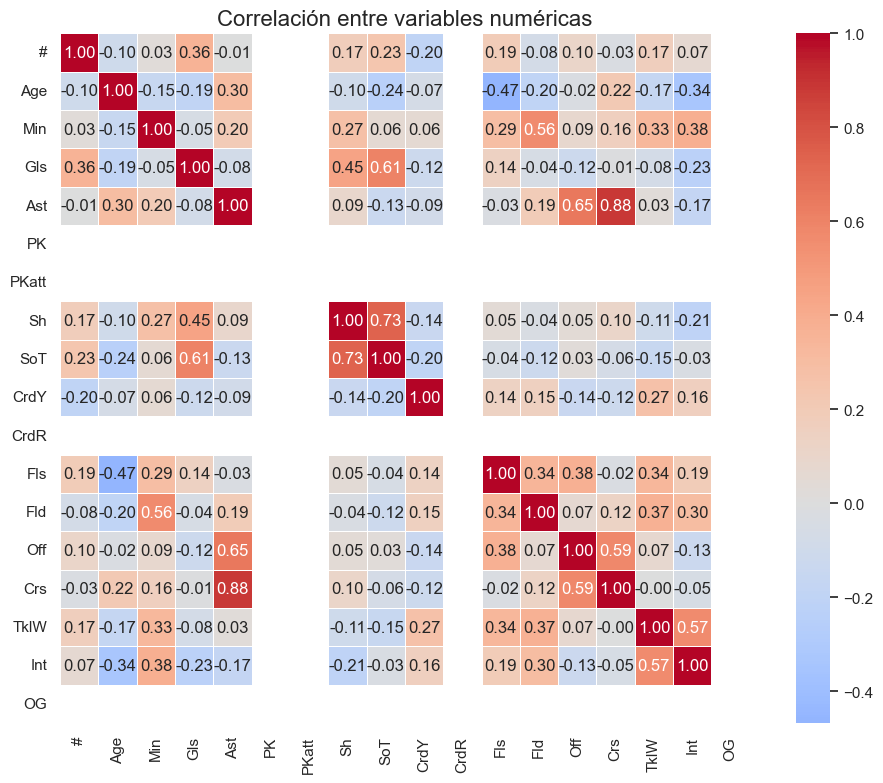

In [30]:
plt.figure(figsize=(10, 8))
correlacion = df_clean[columnas_numericas].corr()

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.grid(False)
plt.show()